In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [115]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

            

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [116]:
len(words)

32033

In [117]:
chars = sorted(list(set(''.join(words))))
stoi ={s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [118]:
def build_dataset(words):
    block_size = 3
    X , Y  = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->' , itos[ix])
    
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 *len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xte ,Yte = build_dataset(words[n2:])

In [119]:
Xtr.shape , Xtr.dtype , Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

In [120]:

C = torch.randn((27,10))
W1 = torch.randn((30 ,200))
b1 = torch.randn(200)
W2 = torch.randn((200 ,27))
b2 = torch.randn(27)
parameters = [C,W1,b1,W2,b2]

In [121]:
sum(p.nelement() for p in parameters)

11897

In [122]:
for p in parameters:
    p.requires_grad = True

In [123]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [124]:
lri = []
lossi = [] 
stepi = []

In [125]:

for i in range(200000):   
    #minibatch construct
    ix = torch.randint(0,Xtr.shape[0] , (32,))
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1,30) @ W1 + b1) #(32,100)
    logits = h @ W2+b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1,keepdims=True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix]) 
    
   
    #backward
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    lr = 0.1 if i< 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())


1.8635035753250122


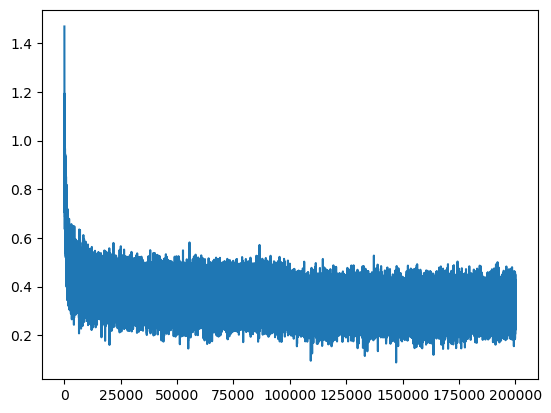

In [126]:
plt.plot(stepi,lossi)

In [127]:
print(loss.item())

1.8635035753250122


In [ ]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30)@W1+b1)# (32 , 100)
logits = h @W2 + b2
loss = F.cross_entropy(logits , Ydev)
loss


In [ ]:
plt.figure(figsize = (8,8))
plt.scatter(C[:,0].data,C[:,1].data , s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i],ha = "center",va = "center", color='white')
plt.grid('minor')

In [134]:
for _ in range(20):
    out =[]
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1)@W1+b1)
        logits = h@W2 +b2
        probs = F.softmax(logits , dim = 1)
        ix = torch.multinomial(probs,num_samples = 1 ).item()
        context = context[1:]+[ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))
        

tremney.
bregha.
khisfmiss.
kharyellin.
estane.
hailah.
khex.
tyndroyenitie.
staino.
lagrif.
quie.
kaylani.
zyr.
mawaddi.
caten.
estyn.
kvyn.
nok.
emintlet.
via.


In [ ]:
import time

for i in range(10):
    print("alive", i)
    time.sleep(1)